In [87]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/graduate-admissions/Admission_Predict.csv
/kaggle/input/graduate-admissions/Admission_Predict_Ver1.1.csv


In [88]:
df= pd.read_csv("/kaggle/input/graduate-admissions/Admission_Predict.csv")

In [89]:
df

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...,...
395,396,324,110,3,3.5,3.5,9.04,1,0.82
396,397,325,107,3,3.0,3.5,9.11,1,0.84
397,398,330,116,4,5.0,4.5,9.45,1,0.91
398,399,312,103,3,3.5,4.0,8.78,0,0.67


In [90]:
df.shape

(400, 9)

In [91]:
df.isnull().sum()

Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         400 non-null    int64  
 1   GRE Score          400 non-null    int64  
 2   TOEFL Score        400 non-null    int64  
 3   University Rating  400 non-null    int64  
 4   SOP                400 non-null    float64
 5   LOR                400 non-null    float64
 6   CGPA               400 non-null    float64
 7   Research           400 non-null    int64  
 8   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 28.3 KB


In [93]:
df.duplicated().sum()

np.int64(0)

In [94]:
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [95]:
df.drop(columns=['Serial No.'], inplace=True)

In [96]:
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [97]:
x=df.iloc[:, 0:-1]
y=df.iloc[:,-1]

In [98]:
from sklearn.model_selection import train_test_split

In [99]:
xtrain , xtest , ytrain , ytest= train_test_split(x,y, test_size=0.2 , random_state=99)

In [100]:
xtrain

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
150,334,114,4,4.0,4.0,9.43,1
6,321,109,3,3.0,4.0,8.20,1
260,327,108,5,5.0,3.5,9.13,1
222,324,113,4,4.5,4.0,8.79,0
220,313,103,3,4.0,4.0,8.75,0
...,...,...,...,...,...,...,...
201,315,110,2,3.5,3.0,8.46,1
168,293,97,2,2.0,4.0,7.80,1
185,327,113,4,4.5,4.5,9.11,1
35,320,110,5,5.0,5.0,9.20,1


In [101]:
# Use min-max scaling

In [102]:
from sklearn.preprocessing import MinMaxScaler
scaler= MinMaxScaler()

In [103]:
xtrain_scaled= scaler.fit_transform(xtrain)
xtest_scaled= scaler.transform(xtest)

In [104]:
xtrain_scaled

array([[0.88      , 0.78571429, 0.75      , ..., 0.75      , 0.84294872,
        1.        ],
       [0.62      , 0.60714286, 0.5       , ..., 0.75      , 0.44871795,
        1.        ],
       [0.74      , 0.57142857, 1.        , ..., 0.625     , 0.74679487,
        1.        ],
       ...,
       [0.74      , 0.75      , 0.75      , ..., 0.875     , 0.74038462,
        1.        ],
       [0.6       , 0.64285714, 1.        , ..., 1.        , 0.76923077,
        1.        ],
       [0.86      , 0.92857143, 1.        , ..., 1.        , 0.81730769,
        1.        ]])

In [105]:
xtrain_scaled.shape


(320, 7)

In [106]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Input , Dense

In [107]:
model = Sequential()
model.add(Input(shape=(7,)))
model.add(Dense(7, activation='relu'))
model.add(Dense(7, activation='relu'))
model.add(Dense(1, activation='linear'))

In [108]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120 (480.00 B)

 Trainable params: 120 (480.00 B)

 Non-trainable params: 0 (0.00 B)

In [109]:
model.compile(loss='mean_squared_error', optimizer='Adam')

In [110]:
history=model.fit(xtrain_scaled , ytrain , epochs=100,validation_split=0.2)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.5211 - val_loss: 0.4367
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3886 - val_loss: 0.3338
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.3078 - val_loss: 0.2529
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2250 - val_loss: 0.1910
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1663 - val_loss: 0.1440
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1272 - val_loss: 0.1089
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0888 - val_loss: 0.0828
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0682 - val_loss: 0.0633
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0536 - val_loss: 0.0486
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0367 - val_loss: 0.0377
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0302 - val_loss: 0.0295
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0207 - val_lo

In [111]:
ypred= model.predict(xtest_scaled)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


In [112]:
from sklearn.metrics import r2_score

In [113]:
r2_score(ytest , ypred)

0.6770250098933162

In [114]:
import matplotlib.pyplot as plt

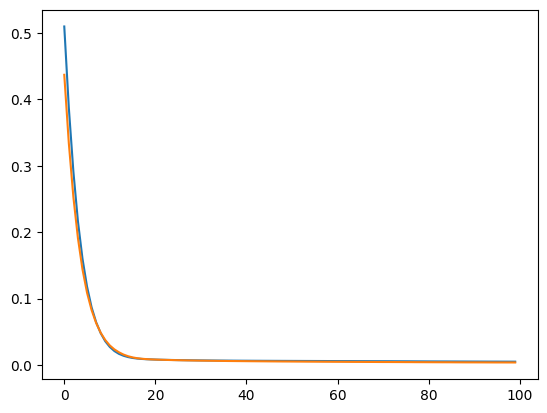

In [115]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])